In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,RocCurveDisplay,PrecisionRecallDisplay
import pickle

In [2]:


url = "https://raw.githubusercontent.com/safdarsidhik/Customer_Churn_Prediction/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Preprocessing

In [3]:
df.drop("customerID", axis=1, inplace=True)

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [5]:
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

/tmp/ipython-input-1408/2364848822.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})


Label encoding of categorical fetaures

In [6]:
# identifying columns with object data type
object_columns = df.select_dtypes(include="object").columns
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [7]:

# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [8]:
# splitting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [9]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print(y_train.shape)

print(y_train.value_counts())

(5634,)
Churn
0    4138
1    1496
Name: count, dtype: int64


5. Model Training

Training with default hyperparameters


In [11]:
model = LGBMClassifier(random_state=42)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


LGBMClassifier(random_state=42)

In [12]:
y_prob = model.predict_proba(X_test)[:, 1]

In [13]:

y_pred_default = (y_prob > 0.5).astype(int)

print("=== Default Threshold (0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_default))

=== Default Threshold (0.5) ===
Accuracy: 0.7998580553584103
ROC-AUC: 0.8512737172254599

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [14]:
threshold = 0.42
y_pred_custom = (y_prob > threshold).astype(int)

print("\n=== Custom Threshold (0.42) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom))


=== Custom Threshold (0.42) ===
Accuracy: 0.7977288857345636
ROC-AUC: 0.8512737172254599

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1036
           1       0.61      0.64      0.62       373

    accuracy                           0.80      1409
   macro avg       0.74      0.75      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [15]:
threshold = 0.42
y_pred_custom = (y_prob > threshold).astype(int)

print("\n=== Custom Threshold (0.42) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom))


=== Custom Threshold (0.42) ===
Accuracy: 0.7977288857345636
ROC-AUC: 0.8512737172254599

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1036
           1       0.61      0.64      0.62       373

    accuracy                           0.80      1409
   macro avg       0.74      0.75      0.74      1409
weighted avg       0.80      0.80      0.80      1409



<Figure size 640x480 with 0 Axes>

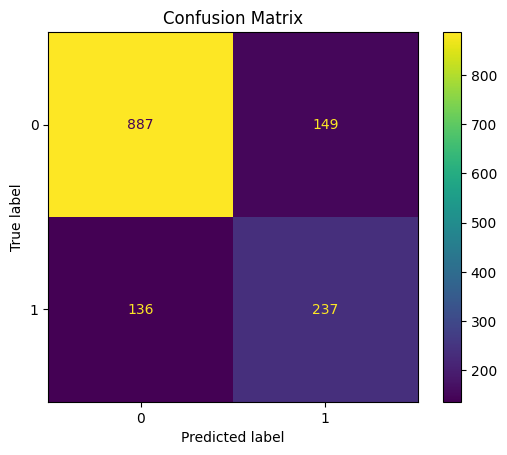

In [16]:
#Confusion Matrix

plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom)
plt.title("Confusion Matrix")
plt.show()

<Figure size 640x480 with 0 Axes>

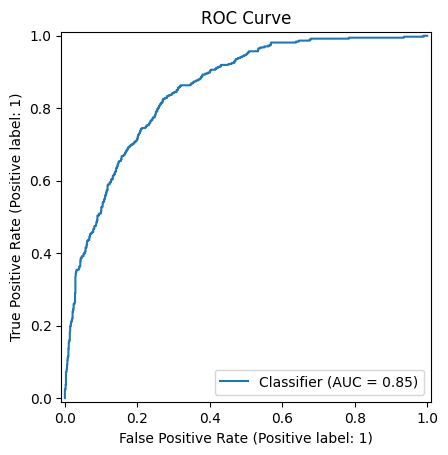

In [17]:
#ROC Curve


plt.figure()
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()


<Figure size 640x480 with 0 Axes>

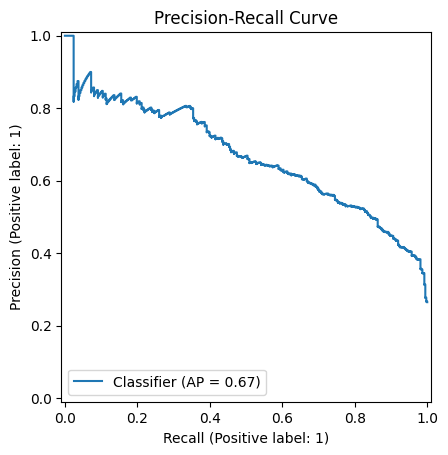

In [18]:
#Precision–Recall Curve

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision-Recall Curve")
plt.show()

In [19]:
with open('lgbm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved to lgbm_model.pkl")

Model saved to lgbm_model.pkl
